# Testing Normality in MLB Rate Stats

This notebook keeps the original experiment: convert common batting and pitching counting stats into rate stats, then ask how close those rate distributions look to normal as the minimum playing-time threshold increases.

A few cleanup changes:

- uses `mlbstatscraping.get_fangraphs_data` instead of the older `stat_scraping` import
- wraps repeated normality-test logic in functions
- reports both Shapiro-Wilk and D'Agostino-Pearson p-values
- clips tiny p-values before plotting on a log scale
- avoids hard-coded output paths

## Imports and Plot Style

In [1]:
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

import mlbstatscraping as ss

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.linewidth": 1.2,
        "font.weight": "medium",
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }
)

pd.set_option("display.max_columns", 100)

## Configuration

The thresholds are the playing-time cutoffs. For batting we use PA; for pitching we use TBF.

In [2]:
YEAR = "2026"
THRESHOLDS = list(range(10, 250, 10))
MIN_LOG10_P = -5

BATTING_STATS = ["H", "HR", "RBI", "R", "SO", "SB"]
PITCHING_STATS = ["H", "HR", "ER", "BB", "W", "SO", "SV"]

OUTPUT_DIR = Path("../data/graphs")
SAVE_FIGURES = False

## Helper Functions

In [3]:
def numeric_series(df, column):
    return pd.to_numeric(df[column], errors="coerce")


def rate_series(df, stat_column, exposure_column, min_exposure):
    stat = numeric_series(df, stat_column)
    exposure = numeric_series(df, exposure_column)
    mask = exposure > min_exposure
    rate = stat.loc[mask] / exposure.loc[mask]
    return rate.replace([np.inf, -np.inf], np.nan).dropna()


def normality_tests(values):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    n = len(values)
    result = {"n": n, "shapiro_p": np.nan, "normaltest_p": np.nan}

    if n >= 3:
        result["shapiro_p"] = stats.shapiro(values).pvalue
    if n >= 8:
        result["normaltest_p"] = stats.normaltest(values).pvalue

    return result


def normality_grid(df, stat_columns, exposure_column, thresholds):
    rows = []
    for stat_column in stat_columns:
        for threshold in thresholds:
            rates = rate_series(df, stat_column, exposure_column, threshold)
            test_result = normality_tests(rates)
            rows.append(
                {
                    "stat": stat_column,
                    "threshold": threshold,
                    "mean_rate": rates.mean(),
                    "median_rate": rates.median(),
                    "std_rate": rates.std(ddof=1),
                    **test_result,
                }
            )
    return pd.DataFrame(rows)


def clipped_log10_p(p_values, min_log10_p=MIN_LOG10_P):
    p_values = pd.to_numeric(pd.Series(p_values), errors="coerce")
    clipped = p_values.clip(lower=10 ** min_log10_p)
    return np.log10(clipped)


def plot_normality_grid(results, title, p_column="shapiro_p", min_log10_p=MIN_LOG10_P):
    fig, ax = plt.subplots(figsize=(7, 4))
    stats_to_plot = list(results["stat"].drop_duplicates())

    for index, stat_column in enumerate(stats_to_plot):
        subset = results.loc[results["stat"] == stat_column].sort_values("threshold")
        color = cm.viridis(index / max(len(stats_to_plot) - 1, 1))
        ax.scatter(
            subset["threshold"],
            clipped_log10_p(subset[p_column], min_log10_p),
            color=color,
            s=24,
            label=stat_column,
        )
        ax.plot(
            subset["threshold"],
            clipped_log10_p(subset[p_column], min_log10_p),
            color=color,
            alpha=0.55,
            linewidth=1,
        )

    ax.axhline(np.log10(0.05), color="grey", linestyle="--", linewidth=1, label="p = 0.05")
    ax.set_ylim(min_log10_p - 0.2, 0.1)
    ax.set_xlabel("Minimum playing-time threshold")
    ax.set_ylabel(f"log10({p_column})")
    ax.set_title(title)
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    return fig, ax


def save_figure(fig, filename):
    if not SAVE_FIGURES:
        return
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")

## Load Fangraphs Data

In [4]:
batting = ss.get_fangraphs_data("hitting", [YEAR])
pitching = ss.get_fangraphs_data("pitching", [YEAR])

print(f"Batters: {len(batting):,}")
print(f"Pitchers: {len(pitching):,}")

batting.head()

Batters: 1,144
Pitchers: 646


,Name,Team,Season,Age,G,AB,PA,H,1B,2B,3B,HR,R,RBI,BB,IBB,SO,HBP,SF,SH,GDP,SB,CS,AVG,GB,FB,LD,Year
0,James Wood,WSN,2026,23.0,57.0,217.0,268.0,60.0,30.0,15.0,0.0,15.0,50.0,37.0,47.0,7.0,78.0,4.0,0.0,0.0,1.0,10.0,1.0,0.276498,54.0,56.0,29.0,2026
1,Zach Neto,LAA,2026,25.0,57.0,223.0,261.0,52.0,28.0,13.0,1.0,10.0,39.0,26.0,32.0,1.0,79.0,5.0,1.0,0.0,0.0,7.0,6.0,0.233184,44.0,64.0,36.0,2026
2,Nico Hoerner,CHC,2026,29.0,56.0,224.0,257.0,57.0,40.0,13.0,0.0,4.0,24.0,32.0,26.0,0.0,20.0,4.0,3.0,0.0,4.0,10.0,1.0,0.254464,82.0,77.0,48.0,2026
3,Alex Bregman,CHC,2026,32.0,56.0,227.0,256.0,59.0,46.0,8.0,1.0,4.0,26.0,17.0,25.0,2.0,44.0,3.0,1.0,0.0,7.0,2.0,1.0,0.259912,77.0,65.0,42.0,2026
4,Gunnar Henderson,BAL,2026,25.0,56.0,238.0,256.0,52.0,28.0,10.0,1.0,13.0,30.0,29.0,15.0,0.0,71.0,2.0,1.0,0.0,2.0,6.0,3.0,0.218487,75.0,65.0,28.0,2026


## Quick Look: Sorted Rate Distributions

This keeps the first visual idea from the original notebook: sorted rate curves make the skew and tail behavior visible before formal testing.

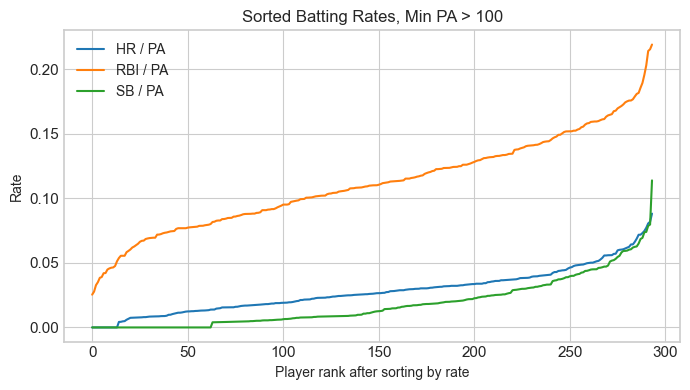

In [5]:
PA_LIMIT = 100

fig, ax = plt.subplots(figsize=(7, 4))
for stat_column in ["HR", "RBI", "SB"]:
    values = rate_series(batting, stat_column, "PA", PA_LIMIT).sort_values().to_numpy()
    ax.plot(values, label=f"{stat_column} / PA")

ax.set_title(f"Sorted Batting Rates, Min PA > {PA_LIMIT}")
ax.set_xlabel("Player rank after sorting by rate")
ax.set_ylabel("Rate")
ax.legend()
fig.tight_layout()

## Batting Normality Across PA Thresholds

In [6]:
batting_results = normality_grid(batting, BATTING_STATS, "PA", THRESHOLDS)
batting_results.head(12)

,stat,threshold,mean_rate,median_rate,std_rate,n,shapiro_p,normaltest_p
0,H,10,0.201893,0.207497,0.055627,490,1.097385e-09,3.719934e-13
1,H,20,0.205107,0.208122,0.046716,459,5.452698e-04,3.490146e-04
2,H,30,0.207675,0.209016,0.042684,429,1.092624e-01,7.090260e-02
3,H,40,0.209005,0.209677,0.041973,405,1.217184e-01,6.215941e-02
4,H,50,0.209678,0.210526,0.040471,390,3.101787e-01,2.095003e-01
5,H,60,0.209806,0.210526,0.039727,371,2.179237e-01,1.098099e-01
6,H,70,0.210698,0.211111,0.038899,352,5.308501e-01,2.518242e-01
7,H,80,0.211285,0.211111,0.038030,337,6.880114e-01,4.392213e-01
8,H,90,0.212371,0.211701,0.037254,316,8.607761e-01,6.328218e-01
9,H,100,0.213064,0.212902,0.037242,294,9.269010e-01,7.212112e-01


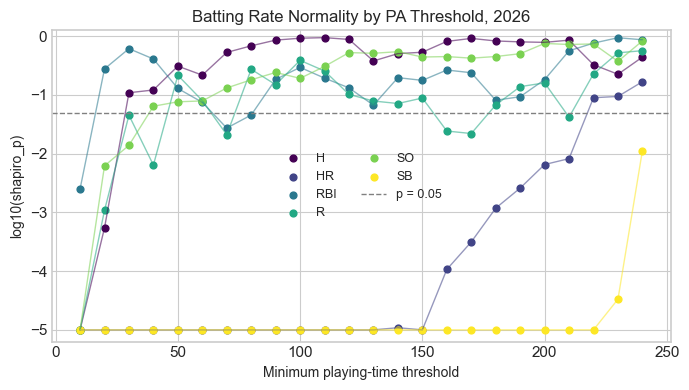

In [7]:
fig, ax = plot_normality_grid(
    batting_results,
    title=f"Batting Rate Normality by PA Threshold, {YEAR}",
    p_column="shapiro_p",
)
save_figure(fig, "batting_convergence_shapiro.png")

## Pitching Normality Across TBF Thresholds

In [8]:
pitching_results = normality_grid(pitching, PITCHING_STATS, "TBF", THRESHOLDS)
pitching_results.head(12)

,stat,threshold,mean_rate,median_rate,std_rate,n,shapiro_p,normaltest_p
0,H,10,0.215762,0.210526,0.065919,587,5.093305e-16,8.153790e-28
1,H,20,0.211076,0.208955,0.053788,527,1.396196e-10,1.209543e-17
2,H,30,0.209973,0.208873,0.048836,486,2.005763e-07,9.833278e-11
3,H,40,0.209427,0.208743,0.047834,458,6.757410e-06,7.266675e-08
4,H,50,0.208186,0.207921,0.044589,417,7.971999e-03,1.516761e-03
5,H,60,0.206867,0.206897,0.042120,398,4.344882e-01,3.824201e-01
6,H,70,0.207928,0.207547,0.041527,367,3.208697e-01,2.880438e-01
7,H,80,0.207422,0.206897,0.041006,338,3.880985e-01,2.168871e-01
8,H,90,0.210862,0.209413,0.038901,286,5.932246e-01,7.011700e-01
9,H,100,0.211209,0.209524,0.036730,237,6.075202e-01,4.209809e-01


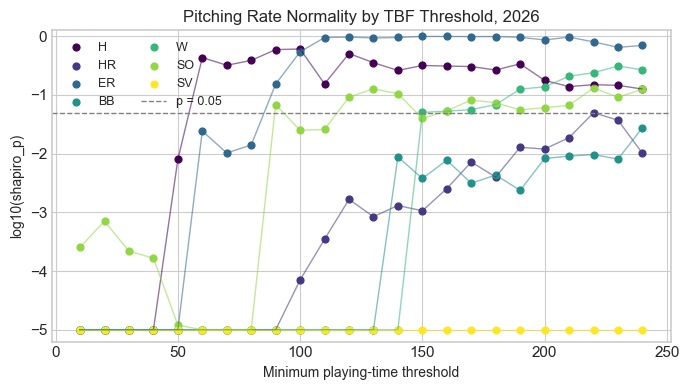

In [9]:
fig, ax = plot_normality_grid(
    pitching_results,
    title=f"Pitching Rate Normality by TBF Threshold, {YEAR}",
    p_column="shapiro_p",
)
save_figure(fig, "pitching_convergence_shapiro.png")

## Compare Shapiro-Wilk and D'Agostino-Pearson

Shapiro-Wilk is usually strong for small to medium samples. D'Agostino-Pearson combines skew and kurtosis and is only available here when at least 8 observations remain after filtering.

In [10]:
comparison = pd.concat(
    [
        batting_results.assign(group="batting", exposure="PA"),
        pitching_results.assign(group="pitching", exposure="TBF"),
    ],
    ignore_index=True,
)

comparison.loc[
    comparison["threshold"].isin([50, 100, 150]),
    ["group", "stat", "threshold", "n", "shapiro_p", "normaltest_p", "mean_rate", "std_rate"],
].sort_values(["group", "stat", "threshold"]).head(30)

,group,stat,threshold,n,shapiro_p,normaltest_p,mean_rate,std_rate
4,batting,H,50,390,3.101787e-01,2.095003e-01,0.209678,0.040471
9,batting,H,100,294,9.269010e-01,7.212112e-01,0.213064,0.037242
14,batting,H,150,209,5.350890e-01,4.915649e-01,0.219245,0.035217
28,batting,HR,50,390,1.244925e-09,8.454177e-08,0.026156,0.017921
33,batting,HR,100,294,3.410823e-07,1.381608e-06,0.028229,0.017290
38,batting,HR,150,209,5.390059e-06,3.181595e-05,0.030817,0.017556
76,batting,R,50,390,2.166952e-01,1.235902e-01,0.112719,0.032224
81,batting,R,100,294,3.889825e-01,9.258207e-01,0.115350,0.028636
86,batting,R,150,209,8.877347e-02,2.230582e-01,0.119452,0.026545
52,batting,RBI,50,390,1.292179e-01,1.587374e-01,0.108825,0.038767


## QQ Plots for a Single Threshold

P-values are useful, but with enough players they can reject normality for tiny deviations. QQ plots show the shape of the deviation.

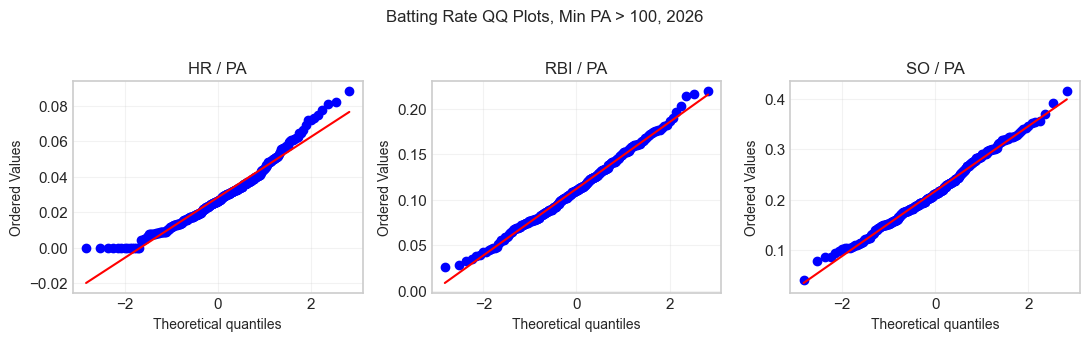

In [11]:
def qq_plot_grid(df, stat_columns, exposure_column, threshold, title):
    ncols = 3
    nrows = int(np.ceil(len(stat_columns) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.3 * nrows))
    axes = np.ravel(axes)

    for axis, stat_column in zip(axes, stat_columns):
        rates = rate_series(df, stat_column, exposure_column, threshold)
        stats.probplot(rates, dist="norm", plot=axis)
        axis.set_title(f"{stat_column} / {exposure_column}")
        axis.grid(alpha=0.25)

    for axis in axes[len(stat_columns):]:
        axis.set_axis_off()

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig, axes


qq_plot_grid(
    batting,
    ["HR", "RBI", "SO"],
    "PA",
    threshold=100,
    title=f"Batting Rate QQ Plots, Min PA > 100, {YEAR}",
);

## Notes

- A small p-value means the normal model is a poor fit for that rate distribution; it does not tell us whether the deviation matters for a specific baseball use case.
- Rate stats bounded below by zero, like HR/PA and SB/PA, are often skewed and may never look especially normal.
- Playing-time thresholds change both sample size and player population. Higher thresholds remove part-time players, which can make the distribution look cleaner for reasons unrelated to convergence.
- A useful follow-up would compare raw rates with transformed rates such as log rates, logit rates, or empirical Bayes-shrunken rates.